In [91]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from scipy.stats import skew, kurtosis
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.sandbox.stats.runs import runstest_1samp
from scipy import stats
warnings.filterwarnings('ignore')

In [92]:
# Преобразуем "сырой" датафрейм
def good_dataframe(data, timeframe):
    
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    
    """
  # 1. Делаем копию, чтобы не изменялся исходный датафрейм
  data = data.copy()
  
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['ticker', 'per', 'date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """

    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'ticker': 'first',
            'per': 'first',
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    

    return_data['per'] = timeframe
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  result = result.reset_index()
  
  return result


In [93]:
def detection_of_inverted_hammer(data, lower_shadow_rate=0.1, body_rate=0.3, up_shadow_rate=2):

    """
    Обнаружение паттерна "Перевернутый молот".
    
    Условия:
        - Тело свечи ≤ 30% от всей свечи
        - Верхняя тень ≥ 10% от тела
        - Нижняя тень ≤ 2× тела
    
    Args:
        data: DataFrame с колонками open, high, low, close
        lower_shadow_rate: макс. соотношение нижней тени к телу (по умолч. 0.1)
        body_rate: макс. соотношение тела к свече (по умолч. 0.3)
        up_shadow_rate: мин. соотношение верхней тени к телу (по умолч. 2)
    
    Returns:
        data с колонками:
            - pattern: 1 - найден паттерн
            - signal: 1 - сигнал на покупку (на следующей свече)
            - strategy: 'inverted_hummer'
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['lower_shadow_rate'] = lower_shadow_rate
    data['up_shadow_rate'] = up_shadow_rate
    data['body_rate'] = body_rate
    data['strategy'] = 'inverted_hummer'
    # Векторизованные вычисления
    full_candle = data['high'] - data['low']
    body = np.abs(data['close'] - data['open'])
    lower_shadow = np.where(data['close'] - data['open'] > 0, data['open'] - data['low'], data['close'] - data['low'])
    up_shadow = np.where(data['close'] - data['open'] > 0, data['high'] - data['close'], data['high'] - data['open'])
    

    # Базовое условие для формации перевернутый молот
    mask = ((body / full_candle < body_rate) & 
                      (lower_shadow / body < lower_shadow_rate) &
                      (up_shadow / body > up_shadow_rate))

    
    data.loc[mask, 'pattern'] = 1

    
    data.loc[mask, 'pattern'] = 1
    data.loc[mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [94]:
# luk = pd.read_csv(r'C:\Users\user\Desktop\Проект 1 года обучения\Проверка эффективности паттернов\Данные для анализа\LKOH.txt')
# luk = good_dataframe(luk, timeframe='4h')
# luk1 = detection_of_inverted_hammer(luk) 
# luk1[luk1['pattern'] == 1]

In [95]:
# Специальная функция для проверки эффективности паттернов 
def filter_min_distance(data, column, N):
    """Некоторые паттерны расположены слишком близко друг к другу, чтобы не было наложения сделок, 
    необходимо удалить все сигналы на покупку, которые появляются во время удержания позиции.
    Время удержания N периодов

    Args:
        data (pd.DataFrame): Преобразованный датафрейм
        'signal' (int64): Сигнальный столбец.
        N (int): Количество периодов, которые мы собираемся удерживать открытую позицию

    Returns:
        data (pd.DataFrame): Исходный датафрейм с отредактированным сигнальным столбцом
    """
    data = data.copy()
    # Получаем все индексы наблюдений где у нас есть сигнал на покупку
    one_index = data[data[column] == 1].index 
    # Получаем разность между этими индексами
    distances = np.diff(one_index)
    # Маска для каждого сигнала. Первый сигнал на покупку всегда True
    mask = [True]
    
    # Перебираем все разности между индексами
    for dist in distances:
        if dist >= N:
            # Если разность между индексами больше N, то все хорошо.
            # Мы добавляем эту сделку в список
            mask.append(True)
        else:
            # Если расстояние меньше, то сделку игнорируем
            mask.append(False)
            
    # Данные для удаления
    to_remove = one_index[np.where(~np.array(mask))[0]]
    data.loc[to_remove, column] = 0
    
    return data


In [96]:
# Готовим данные для дальнейшей проверки
def data_prepare_for_statistics_1candle(data, commission=0.00025):
    """Функция предназначена для обработки результатов стратегий.

    Args:
        data (pd.DataFrame): на вход подается размеченный датафрейм с колонкой 'signal'
        commission (float, optional): Размер комисии в долях процента (0.00025 ~ 0.025%). Defaults to 0.00025.

    Returns:
        list: Возвращаем список с датафреймами, каждый датафрейм это данные по каждой сделке (дата и размер прибыли в %)
    """
    data = data.copy()
    # Удалим сперва все отметки паттерна и сигнала с последних 51 строки
    data.loc[len(data) - 51 : len(data), ['pattern', 'signal']] = 0
    
    # Проходимся циклом по периодам удержания позиции
    all_strategy = []
    for N in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
        data_h = filter_min_distance(data, 'signal', N) # Получаем фильтрованные данные
        data_h = data_h.set_index('time')
        # Блок для определения цены входа и выхода
        # То есть для каждой стратегии мы определяем вектора цен открытий и закрытий
        # Так как удерживаем позицию мы N периодов, то в качестве всех кандидатов, 
        # на которых мы можем закрыть позицию берем цены открытия через N периодов
        
        exit_candidate = data_h['open'].shift(-N) 
        is_entry = data_h['signal'] == 1
        entry_price = data_h['open'][is_entry]
        exit_price = exit_candidate[is_entry]
        
        # Считаем результат
        gross_profit = exit_price.values - entry_price.values
        commissions = exit_price.values * commission + entry_price.values * commission
        net_profit = gross_profit - commissions
        percent_profit_net = pd.Series(np.round(net_profit / entry_price.values, 5), index=entry_price.index,
                               name='profit_percent') # % доход за сделку
        percent_profit_without_commission = pd.Series(np.round(gross_profit / entry_price.values, 5), index=entry_price.index,
                               name='gross_profit_percent') # % доход за сделку грязный
        
        strategy_data = pd.DataFrame({'profit_percent_net' : np.array(percent_profit_net), 
                                      'percent_profit_without_commission' : np.array(percent_profit_without_commission),
                                       'N' : N, 
                                       'strategy_name' : data_h['strategy'].iloc[0],
                                       'ticker' : data_h['ticker'].iloc[0],
                                       'period' : data_h['per'].iloc[0],
                                       'lower_shadow_rate' : data_h['lower_shadow_rate'].iloc[0],
                                       'up_shadow_rate' : data_h['up_shadow_rate'].iloc[0],
                                       'body_rate' : data_h['body_rate'].iloc[0]},
                            index=percent_profit_net.index)
        all_strategy.append(strategy_data)
        
    return all_strategy



In [97]:
# Функция для получения результатов стратегии
def trade_statistics_bull(all_strategy_data):
    """Функция предназначена для агрегирования результатов стратегий по основным финансовым метрикам

    Args:
        all_strategy_data (list): Подаётся список с датафреймами, где для для каждой сделки установлено время и размер прибыли в %.

    Returns:
        data (pd.DataFrame): Возвращаем новый датафрейм со всеми необходимыми метриками для оценки стратегий.
    """
    capital = 100_000
    strategies = []
    for strategy in all_strategy_data:
        
        # Считаем основные метрики
        ticker = strategy['ticker'].iloc[0]
        strategy_name = strategy['strategy_name'].iloc[0]
        period = strategy['period'].iloc[0]
        N = strategy['N'].iloc[0]
        lower_shadow_rate = strategy['lower_shadow_rate'].iloc[0]
        up_shadow_rate = strategy['up_shadow_rate'].iloc[0]
        body_rate = strategy['body_rate'].iloc[0]
        count_of_trades = len(np.array(strategy['profit_percent_net']))
        profit_percent_net = strategy['profit_percent_net']
        percent_profit_without_commission = strategy['percent_profit_without_commission']
        
        # Кривая капитала 
        capital_curve_net = capital * np.cumprod(1 + strategy['profit_percent_net'])
        capital_curve_without_commission = capital * np.cumprod(1 + strategy['percent_profit_without_commission'])
        
        # Профит фактор
        pr_per_net = np.array(strategy['profit_percent_net'])
        profit_factor = np.round(np.sum(pr_per_net[pr_per_net > 0]) / np.abs(np.sum(pr_per_net[pr_per_net < 0])), 3)
        
        # Общий % доход !!!
        total_per_return_r = np.array(np.cumprod(1 + strategy['profit_percent_net']))[-1]
        total_per_return = np.round((total_per_return_r - 1) * 100, 2)
        
        # Win_rate 
        win_rate = np.round(np.mean(pr_per_net > 0), 2)
        
        # R2
        X = np.array(list(range(len(capital_curve_net)))).reshape(-1, 1)
        y = np.array(capital_curve_net)
        lin = LinearRegression()
        lin.fit(X, y)
        y_pred = lin.predict(X)
        r2 = np.round(metrics.r2_score(y, y_pred), 2)
        
        # Средняя убыточная и прибыльная сделка 
        mean_profit_trade = np.round(np.mean(pr_per_net[pr_per_net > 0]), 3)
        mean_loss_trade = np.round(np.mean(pr_per_net[pr_per_net < 0]), 3)
        avg_profit_loss_ratio = np.round(mean_profit_trade / mean_loss_trade, 3)
        
        # Максимальная просадка
        cumsum_profit = np.cumsum(pr_per_net)
        cummax_profit = np.maximum.accumulate(cumsum_profit)
        max_drawdown = np.max(cummax_profit - cumsum_profit)
        
        strategies.append({
          'ticker' : ticker,
          'strategy name' : strategy_name,
          'period' : period,
          'N' : N,
          'lower_shadow_rate' : lower_shadow_rate,
          'up_shadow_rate' : up_shadow_rate,
          'body_rate' : body_rate,
          'count of trades' : count_of_trades,
          'profit factor' : profit_factor,
          'total percent return' : total_per_return,
          'R2' : r2,
          'win_rate' : win_rate,
          'mean profit (%)' : mean_profit_trade * 100,
          'mean loss (%)' : mean_loss_trade * 100,
          'profit/loss ratio' : np.round(np.abs(avg_profit_loss_ratio), 2),
          'max drawdown (%)' : np.round(max_drawdown * 100, 1),
          'capital curve net' : capital_curve_net,
          'capital curve without commission' : capital_curve_without_commission,
          'profit percent net' : profit_percent_net,
          'percent profit without commission' : percent_profit_without_commission}
          )
        
    return pd.DataFrame(strategies)


In [98]:
# Проверяем стратегии на множестве ТФ.
def backtest_strategies_multi_tf():
    """Функция позволяет проверить эффективность стратегии бычье поглощение на 7 основных таймфреймах.
    На выходе получаем большую сводную таблицу по результатам стратегии на всех таймфреймах.

    Args:
        data (pd.DataFrame): Подаем датафрейм с 1 минутным таймфреймом

    Returns:
        data (pd.DataFrame): Таблица с результатами всех стратегий
    """
    l = []
    # Перебираем все тф
    for a in [r'C:\Users\user\Desktop\Проект 1 года обучения\Проверка эффективности паттернов\Данные для анализа\ROSN.txt']:
        data = pd.read_csv(a)
        for i in ['5 min', '15 min', '30 min', '1h', '2h', '4h']:
            data_tm = good_dataframe(data, i)
            l.append(data_tm)
        
        all_strategy = []
        # Для каждого тф проверяем стратегию бычье поглощение
        for j in l:
            for func in [detection_of_inverted_hammer]:
                for lower_rate in [0.05, 0.1]:
                    for up_rate in [2, 2.5, 3]:
                        for body_rate in [0.1, 0.2, 0.3]:
                            detection_data = func(j, lower_shadow_rate=lower_rate, up_shadow_rate=up_rate, body_rate=body_rate)
                            result = data_prepare_for_statistics_1candle(detection_data)
                            final_result = trade_statistics_bull(result)
                            all_strategy.append(final_result)
        # Объединяем результат   
        combined_data = pd.concat(all_strategy, ignore_index=True)
    
    return combined_data

sber_result_strategies = backtest_strategies_multi_tf()
sber_result_strategies.head(3)

,ticker,strategy name,period,N,lower_shadow_rate,up_shadow_rate,body_rate,count of trades,profit factor,total percent return,R2,win_rate,mean profit (%),mean loss (%),profit/loss ratio,max drawdown (%),capital curve net,capital curve without commission,profit percent net,percent profit without commission
0,ROSN,inverted_hummer,5 min,1,0.05,2.0,0.1,1206,0.312,-51.88,0.99,0.28,0.1,-0.1,1.0,72.8,time 2009-01-11 15:20:00 99774.000000 2009-...,time 2009-01-11 15:20:00 99824.000000 2009-...,time 2009-01-11 15:20:00 -0.00226 2009-01-12...,time 2009-01-11 15:20:00 -0.00176 2009-01-12...
1,ROSN,inverted_hummer,5 min,2,0.05,2.0,0.1,1199,0.439,-51.46,0.99,0.31,0.2,-0.2,1.0,72.0,time 2009-01-11 15:20:00 99871.000000 2009-...,time 2009-01-11 15:20:00 99921.000000 2009-...,time 2009-01-11 15:20:00 -0.00129 2009-01-12...,time 2009-01-11 15:20:00 -0.00079 2009-01-12...
2,ROSN,inverted_hummer,5 min,3,0.05,2.0,0.1,1193,0.521,-52.51,0.99,0.36,0.2,-0.2,1.0,74.6,time 2009-01-11 15:20:00 99827.000000 2009-...,time 2009-01-11 15:20:00 99877.000000 2009-...,time 2009-01-11 15:20:00 -0.00173 2009-01-12...,time 2009-01-11 15:20:00 -0.00123 2009-01-12...


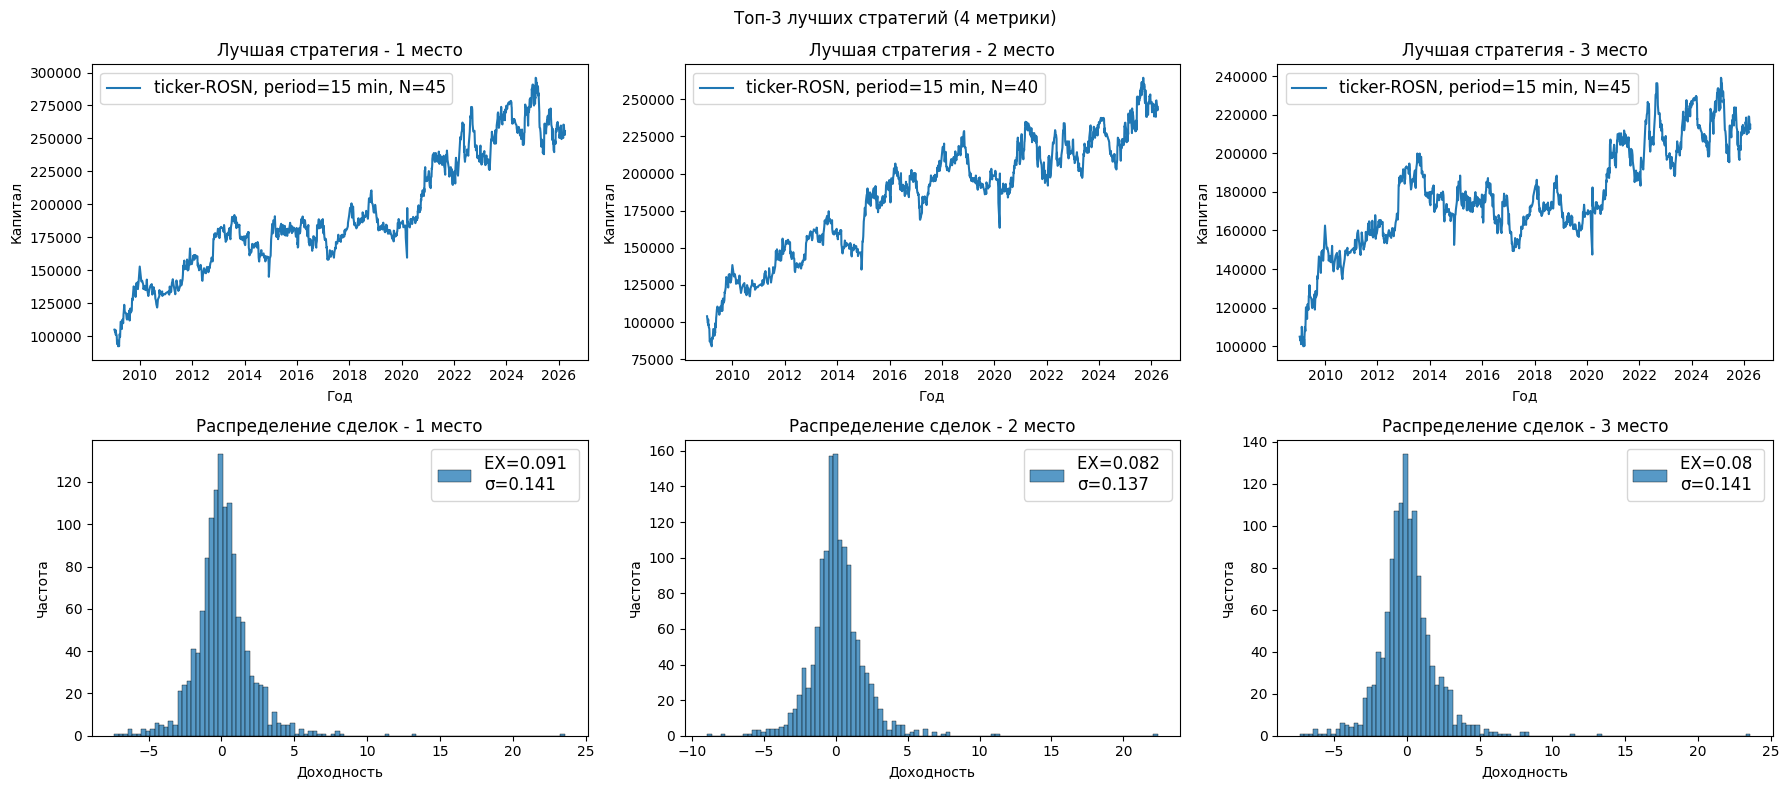

,ticker,strategy name,period,N,lower_shadow_rate,up_shadow_rate,body_rate,count of trades,profit factor,mean profit (%),mean loss (%),profit/loss ratio,max drawdown (%),total percent return,R2,win_rate
0,ROSN,inverted_hummer,15 min,45,0.05,2.0,0.3,1299,1.147,1.5,-1.2,1.25,26.6,155.31,0.88,0.49
1,ROSN,inverted_hummer,15 min,40,0.05,2.0,0.3,1383,1.140,1.4,-1.1,1.27,32.2,144.92,0.85,0.48
2,ROSN,inverted_hummer,15 min,45,0.05,2.5,0.3,1252,1.129,1.5,-1.2,1.25,25.7,114.72,0.70,0.48
3,ROSN,inverted_hummer,15 min,50,0.05,2.5,0.3,1157,1.185,1.5,-1.2,1.25,38.5,204.11,0.78,0.49
4,ROSN,inverted_hummer,15 min,50,0.05,3.0,0.3,1039,1.169,1.5,-1.2,1.25,32.2,142.09,0.72,0.49
5,ROSN,inverted_hummer,15 min,40,0.05,2.5,0.3,1328,1.118,1.4,-1.1,1.27,28.8,100.52,0.66,0.47
6,ROSN,inverted_hummer,15 min,50,0.05,2.0,0.3,1201,1.183,1.5,-1.3,1.15,30.1,215.43,0.86,0.49
7,ROSN,inverted_hummer,15 min,35,0.05,2.0,0.3,1472,1.128,1.3,-1.1,1.18,27.3,129.05,0.66,0.49
8,ROSN,inverted_hummer,15 min,35,0.10,2.0,0.3,1512,1.107,1.3,-1.1,1.18,29.3,99.31,0.76,0.49
9,ROSN,inverted_hummer,15 min,45,0.10,2.5,0.3,1269,1.101,1.5,-1.2,1.25,27.0,75.71,0.63,0.48


In [99]:
# Функция для первичного отбора стратегий
def compare_strategies(data):
    """Функция предназначена для сравнения полученных стратегий и выявления наилучших претендентов
    для дальнейшего анализа.

    Args:
        data (pd.DataFrame): Датафрейм с результатами стратегий
    Returns:
        data (pd.DaraFrame): Возвращаем отфильтрованный датафрейм со результатами стратегии на всех тайфреймах.
    """
    # Фильтрация стратегий
    data = data[(data['count of trades'] > 800) & (data['profit factor'] > 1) & (data['total percent return'] > 0) & (data['R2'] > 0.5)] # Ограничение по количеству сделок
    if data.shape[0] != 0:
        data['profit factor rank'] = data['profit factor'].rank() # Больше лучше
        data['R2 rank'] = data['R2'].rank() # Больше лучше
        data['profit/loss ratio rank'] = data['profit/loss ratio'].rank() # Больше лучше
        data['max drawdown rank'] = data['max drawdown (%)'].rank(ascending=False) # Меньше лучше
        data['best model'] = data['profit factor rank'] + data['R2 rank'] + data['profit/loss ratio rank'] + data['max drawdown rank']
        
        # Построение графиков 3 лучших стратегий
        
        data.sort_values('best model', ascending=False, inplace=True, ignore_index=True)
        if data.shape[0] >= 3:    
            # График
            fig, axes = plt.subplots(2, 3, figsize=(18, 8))
            plt.suptitle('Топ-3 лучших стратегий (4 метрики)')
            
            # Первые 3 графика
            sns.lineplot(data.loc[0, 'capital curve net'], ax=axes[0, 0], label=f'ticker-{data.loc[0, 'ticker']}, period={data.loc[0, 'period']}, N={data.loc[0, 'N']}');
            sns.lineplot(data.loc[1, 'capital curve net'], ax=axes[0, 1], label=f'ticker-{data.loc[1, 'ticker']}, period={data.loc[1, 'period']}, N={data.loc[1, 'N']}');
            sns.lineplot(data.loc[2, 'capital curve net'], ax=axes[0, 2], label=f'ticker-{data.loc[2, 'ticker']}, period={data.loc[2, 'period']}, N={data.loc[2, 'N']}');
            axes[0, 0].legend(fontsize=12)
            axes[0, 1].legend(fontsize=12)
            axes[0, 2].legend(fontsize=12)
            
            axes[0, 0].set_title('Лучшая стратегия - 1 место')
            axes[0, 1].set_title('Лучшая стратегия - 2 место')
            axes[0, 2].set_title('Лучшая стратегия - 3 место')
            axes[0, 0].set_ylabel('Капитал')
            axes[0, 1].set_ylabel('Капитал')
            axes[0, 2].set_ylabel('Капитал')
            axes[0, 0].set_xlabel('Год')
            axes[0, 1].set_xlabel('Год')
            axes[0, 2].set_xlabel('Год')
            
            # Вторые 3 графика
            sns.histplot(data.loc[0, 'profit percent net'] * 100, ax=axes[1, 0], bins=100, 
                            label=f'EX={np.round(np.mean(data.loc[0, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit percent net"])),3)}');
            sns.histplot(data.loc[1, 'profit percent net'] * 100, ax=axes[1, 1], bins=100,
                            label=f'EX={np.round(np.mean(data.loc[1, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit percent net"])),3)}');
            sns.histplot(data.loc[2, 'profit percent net'] * 100, ax=axes[1, 2], bins=100,
                            label=f'EX={np.round(np.mean(data.loc[2, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit percent net"])),3)}');
            axes[1, 0].legend(fontsize=12)
            axes[1, 1].legend(fontsize=12)
            axes[1, 2].legend(fontsize=12)
                
            axes[1, 0].set_title('Распределение сделок - 1 место')
            axes[1, 1].set_title('Распределение сделок - 2 место')
            axes[1, 2].set_title('Распределение сделок - 3 место')
            axes[1, 0].set_ylabel('Частота')
            axes[1, 1].set_ylabel('Частота')
            axes[1, 2].set_ylabel('Частота')
            axes[1, 0].set_xlabel('Доходность')
            axes[1, 1].set_xlabel('Доходность')
            axes[1, 2].set_xlabel('Доходность')
                
            plt.tight_layout()
            plt.show()
            data_new = data[['ticker', 'strategy name', 'period', 'N', 'lower_shadow_rate', 'up_shadow_rate', 'body_rate', 'count of trades',
            'profit factor', 'mean profit (%)', 'mean loss (%)', 'profit/loss ratio', 'max drawdown (%)', 'total percent return', 'R2', 'win_rate']]
            display(data_new.head(10))       
            return data
        else:
            data_new = data[['ticker', 'strategy name', 'period', 'N', 'lower_shadow_rate', 'up_shadow_rate', 'body_rate', 'count of trades',
            'profit factor', 'mean profit (%)', 'mean loss (%)', 'profit/loss ratio', 'max drawdown (%)', 'total percent return', 'R2', 'win_rate']]
            display(data_new.head(10))
            return data  
            
    else:
        print('ХОРОШИХ СТРАТЕГИЙ НЕТ')
    
res = compare_strategies(sber_result_strategies)

In [100]:
import pickle 
with open(r'C:\Users\user\Desktop\Проект 1 года обучения\Повышение эффективности с помощью ML\Результаты паттернов\results_strategies_1candle_rosneft.pkl', 'wb') as file:
    pickle.dump(res, file)